# Introduction / Business Understanding

Citizen science websites collect biodiversity observations from people.

This data helps researchers monitor species and understand biodiversity patterns.

However, the data can contain bias because some places, seasons and observers have more observations than others.

Our goal is to predict whether Corvus corone is observed at a specific location and date.

# Data Loading

We loaded the GBIF biodiversity dataset for Corvus corone.

In [35]:
import pandas as pd
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
RAW_DATA = PROJECT_ROOT / "data" / "raw" / "Corvus corone.csv.zip"

with zipfile.ZipFile(RAW_DATA, "r") as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

df.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34400\4147508343.py:12: DtypeWarning: Columns (0: Corvus corone) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Corvus corone
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,25.0,25,1
2,50.75,5.65,2010-01-03,3.0,3,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


# Data Understanding

The dataset contains date, latitude, longitude, observation counts and sampling-effort variables.

In [9]:
df.shape

(12558786, 6)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Corvus corone              object 
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 574.9+ MB


In [11]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,month
count,1.255879e+07,1.255879e+07,12558786,1.255878e+07,1.255879e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,2017-12-31 12:10:06.165595,8.056834e+00,4.314087e+00,6.522916e+00
min,3.500000e+00,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,1.000000e+00
25%,5.170000e+01,4.900000e+00,2014-01-01 00:00:00,0.000000e+00,0.000000e+00,4.000000e+00
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00,7.000000e+00
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,2.000000e+00,1.000000e+01
max,5.350000e+01,5.340000e+01,2026-01-30 00:00:00,1.000390e+05,2.781000e+03,1.200000e+01
std,6.647267e-01,8.779710e-01,NaN,4.821959e+01,1.610809e+01,3.448710e+00


In [12]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Corvus corone,month
0,50.75,5.65,2010-01-01,0.0,0,0,1
1,50.75,5.65,2010-01-02,25.0,25,1,1
2,50.75,5.65,2010-01-03,3.0,3,0,1
3,50.75,5.65,2010-01-04,0.0,0,0,1
4,50.75,5.65,2010-01-05,0.0,0,0,1


# Data Quality

We checked missing values, duplicates and data types.

In [14]:
df.isnull().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Corvus corone                0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

decimalLatitude              float64
decimalLongitude             float64
eventDate                        str
total_observations           float64
speciesgroup_observations      int64
Corvus corone                 object
dtype: object

# Data Cleaning

We removed duplicates, converted dates and handled missing values.

In [17]:
df = df.drop_duplicates()

df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")

numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Corvus corone
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,25.0,25,1
2,50.75,5.65,2010-01-03,3.0,3,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


# Feature Engineering

We created time-based features and a binary target variable.

## Target Variable: Observed vs Not Observed

The original column `Corvus corone` contains the number of observations for this species at a specific location and date.

For this project, we converted this numeric count into a binary target variable called `target_class`.

- `0` means **not observed**
- `1` means **observed**

In this context, **observed** means that at least one Corvus corone observation was recorded for that specific location and date.

If the value of `Corvus corone` is 0, then no observation was recorded, so the target becomes 0.

If the value of `Corvus corone` is greater than 0, then at least one observation was recorded, so the target becomes 1.

We made this conversion because the dataset contains many zero values. Instead of predicting the exact number of observations, we first focus on predicting whether the species was observed or not. This makes the problem a binary classification task.

In [18]:
df["month"] = df["eventDate"].dt.month
df["year"] = df["eventDate"].dt.year
df["day_of_week"] = df["eventDate"].dt.dayofweek

In [19]:
df["Corvus corone"] = pd.to_numeric(
    df["Corvus corone"],
    errors="coerce"
).fillna(0)

df["target_class"] = (df["Corvus corone"] > 0).astype(int)

df[["eventDate", "month", "year", "day_of_week", "Corvus corone", "target_class"]].head()

,eventDate,month,year,day_of_week,Corvus corone,target_class
0,2010-01-01,1,2010,4,0.0,0
1,2010-01-02,1,2010,5,1.0,1
2,2010-01-03,1,2010,6,0.0,0
3,2010-01-04,1,2010,0,0.0,0
4,2010-01-05,1,2010,1,0.0,0


In [20]:
df["target_class"].value_counts()

target_class
0    11946959
1      611827
Name: count, dtype: int64

# Representativity Bias

Citizen science data may not be representative because observations are not evenly distributed across seasons and locations.

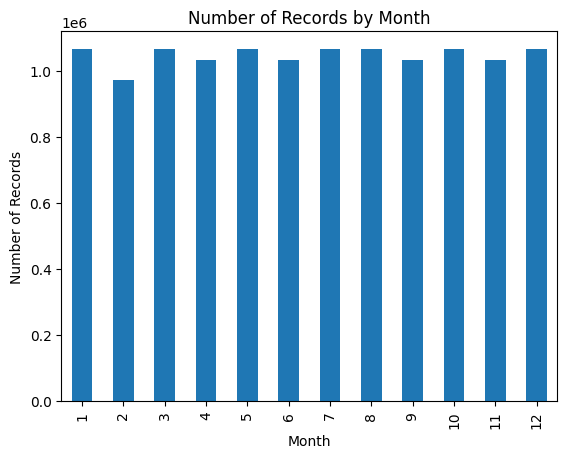

In [21]:
df["month"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Records by Month")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.show()

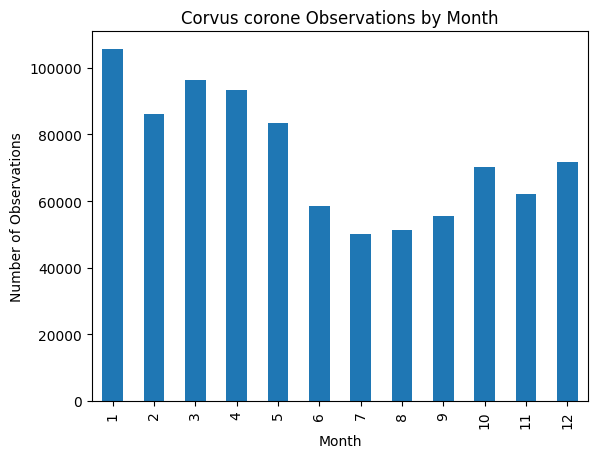

In [22]:
df.groupby("month")["Corvus corone"].sum().plot(kind="bar")
plt.title("Corvus corone Observations by Month")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.show()

The map shows that observations are not evenly distributed across locations, which suggests spatial representativity bias.

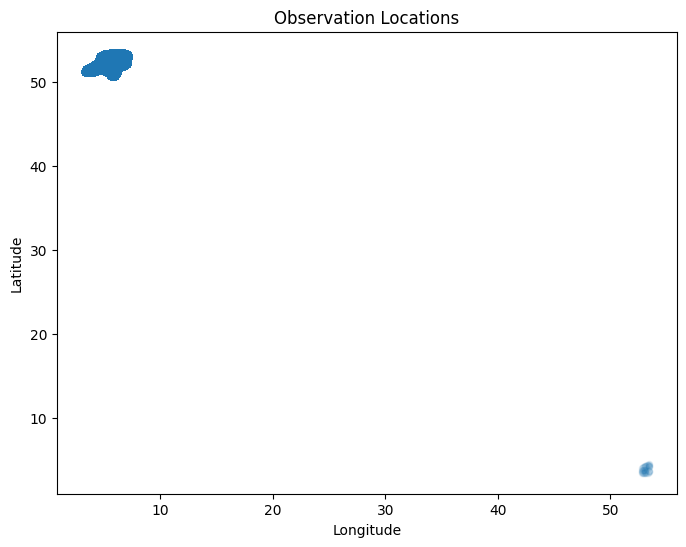

In [29]:
df.plot(
    kind="scatter",
    x="decimalLongitude",
    y="decimalLatitude",
    alpha=0.1,
    figsize=(8,6)
)

plt.title("Observation Locations")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# Exploratory Data Analysis

We explored seasonal patterns and class imbalance.

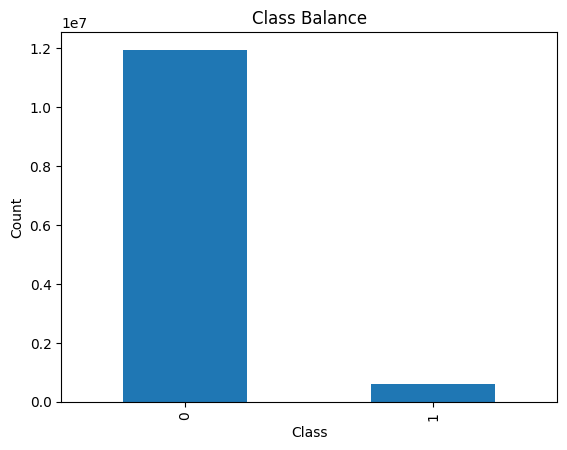

In [23]:
df["target_class"].value_counts().plot(kind="bar")
plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

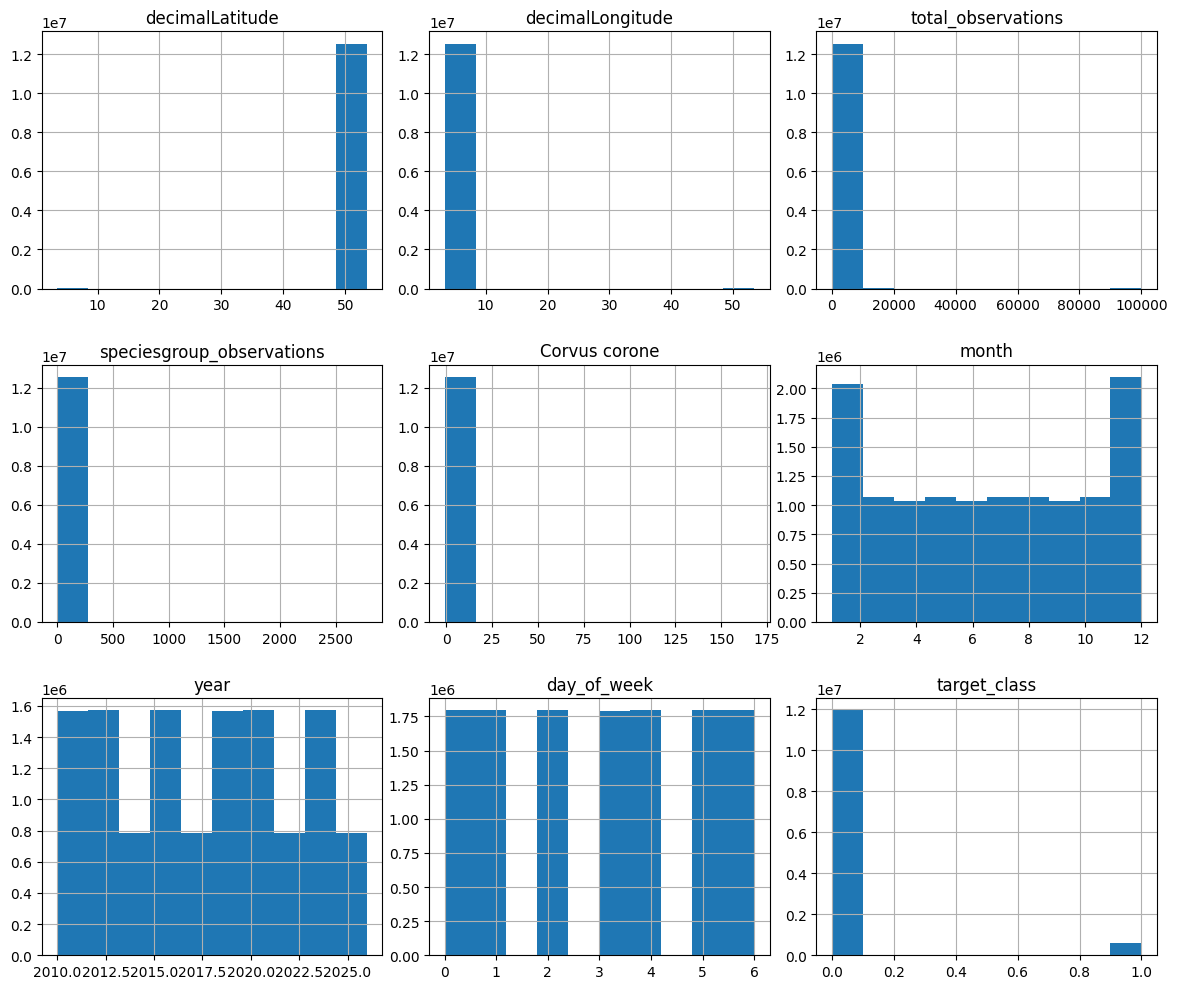

In [24]:
numeric_cols = df.select_dtypes(include=["number"])

numeric_cols.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Data Preparation

We prepared the dataset for machine learning.

Missing values:
- numerical missing values were replaced with 0

Encoding:
- additional encoding was not required because the selected features are numerical

Scaling:
- scaling was not applied because Random Forest does not require feature scaling

In [25]:
features = [
    "decimalLatitude",
    "decimalLongitude",
    "month",
    "year",
    "day_of_week",
    "total_observations",
    "speciesgroup_observations"
]

features = [col for col in features if col in df.columns]

X = df[features].fillna(0)
y = df["target_class"]

X.head()

,decimalLatitude,decimalLongitude,month,year,day_of_week,total_observations,speciesgroup_observations
0,50.75,5.65,1,2010,4,0.0,0
1,50.75,5.65,1,2010,5,25.0,25
2,50.75,5.65,1,2010,6,3.0,3
3,50.75,5.65,1,2010,0,0.0,0
4,50.75,5.65,1,2010,1,0.0,0


# Modeling Approach

We use classification because the target has two classes:

0 = not observed  
1 = observed

We selected a Random Forest Classifier because it works well for classification and can handle multiple numerical features.

## Success Criteria

The project will be considered successful if the model achieves:

- an F1-score above 0.70
- balanced precision and recall scores
- better performance than random guessing

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Evaluation

We use precision, recall and F1-score because the dataset is imbalanced.

In [27]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98   2389393
           1       0.61      0.26      0.36    122365

    accuracy                           0.96   2511758
   macro avg       0.79      0.62      0.67   2511758
weighted avg       0.95      0.96      0.95   2511758



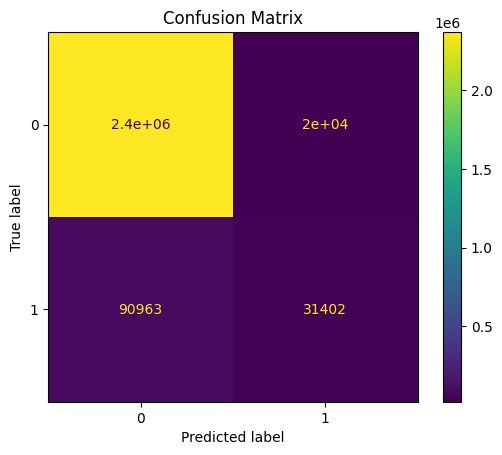

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Confusion Matrix")
plt.show()

# Conclusion / Next Steps

So far, we completed:
- business understanding
- data understanding
- feature engineering
- exploratory data analysis
- classification modeling

Future improvements could include:
- land-use variables
- forest coverage
- habitat information
- environmental variables